# LaBraM event window adaptation

Visualize several event windows before and after the LaBraM-specific adaptation used by the benchmark pipeline. The adapter mutates each window dataset transform, so this notebook clones unadapted samples before applying the LaBraM transform.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from eeg_benchmark.adapters import adapt_windows_to_model
from eeg_benchmark.datasets import MOABBDatasetWrapper, split_train_test
from eeg_benchmark.models import MODELS

In [16]:
DATASET_NAME = "BNCI2014_001"
MODEL_NAME = "labram"
EVENT_COUNT = 8
SIGNAL_CHANNEL = "C3"
WINDOW_GAP_SECONDS = 0.25
CHANNEL_COUNT = 5

In [10]:
dataset = MOABBDatasetWrapper.load(DATASET_NAME)
model = MODELS[MODEL_NAME].load(device="cpu")

sfreq = float(dataset.dataset.datasets[0].raw.info["sfreq"])
id_to_event = {value: key for key, value in dataset.event_mapping.items()}
signal_channel = SIGNAL_CHANNEL if SIGNAL_CHANNEL in dataset.channel_names else dataset.channel_names[0]
channels_to_plot = dataset.channel_names[:CHANNEL_COUNT]

pd.DataFrame(
    [
        {
            "dataset": dataset.dataset_name,
            "model": MODEL_NAME,
            "sampling_hz": sfreq,
            "channels": len(dataset.channel_names),
            "classes": len(dataset.event_mapping),
            "target_window_samples": model.input_window_samples,
            "target_window_seconds": model.input_window_samples / sfreq,
            "split_plot_channel": signal_channel,
            "plotted_channels": ", ".join(channels_to_plot),
        }
    ]
)

,dataset,model,sampling_hz,channels,classes,target_window_samples,target_window_seconds,split_plot_channel,plotted_channels
0,BNCI2014_001,labram,250.0,22,4,3000,12.0,C3,"Fz, FC3, FC1, FCz, FC2"


## Event-window split

In [11]:
windows = dataset.create_event_windows()
first_window_dataset = windows.datasets[0]
window_metadata = first_window_dataset.metadata.head(EVENT_COUNT).copy()
window_metadata["event"] = window_metadata["target"].astype(int).map(id_to_event)
window_metadata["duration_samples"] = (
    window_metadata["i_stop_in_trial"] - window_metadata["i_start_in_trial"]
)
window_metadata["duration_seconds"] = window_metadata["duration_samples"] / sfreq

display(window_metadata)

,i_window_in_trial,i_start_in_trial,i_stop_in_trial,target,event,duration_samples,duration_seconds
0,0,750,1750,3,tongue,1000,4.0
1,0,2753,3753,0,feet,1000,4.0
2,0,4671,5671,2,right_hand,1000,4.0
3,0,6623,7623,1,left_hand,1000,4.0
4,0,8631,9631,1,left_hand,1000,4.0
5,0,10742,11742,2,right_hand,1000,4.0
6,0,12659,13659,0,feet,1000,4.0
7,0,14709,15709,3,tongue,1000,4.0


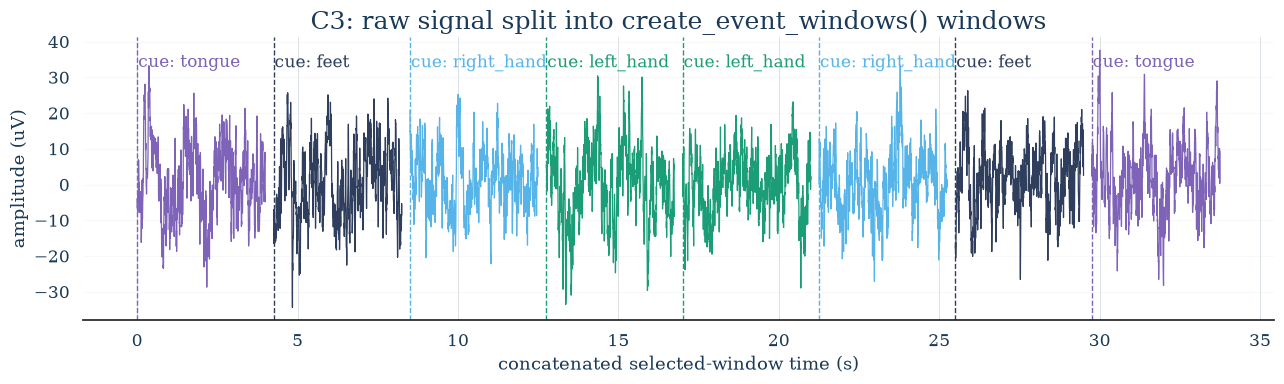

In [12]:
event_colors = {
    event_name: color
    for event_name, color in zip(
        sorted(dataset.event_mapping),
        plt.rcParams["axes.prop_cycle"].by_key()["color"],
        strict=False,
    )
}

raw = first_window_dataset.raw
signal_segments = []
cursor_s = 0.0
for _, row in window_metadata.iterrows():
    start_sample = int(row["i_start_in_trial"])
    stop_sample = int(row["i_stop_in_trial"])
    values = raw.get_data(
        picks=[signal_channel],
        start=start_sample,
        stop=stop_sample,
    )[0]
    local_time_s = np.arange(values.shape[-1]) / sfreq
    signal_segments.append(
        {
            "event": row["event"],
            "values": values,
            "time_s": local_time_s + cursor_s,
            "cue_x_s": cursor_s,
        }
    )
    cursor_s += values.shape[-1] / sfreq + WINDOW_GAP_SECONDS

fig, ax = plt.subplots(figsize=(13, 4))
for segment in signal_segments:
    event_name = segment["event"]
    ax.plot(
        segment["time_s"],
        segment["values"],
        color=event_colors[event_name],
        linewidth=0.9,
    )

y_min, y_max = ax.get_ylim()
label_y = y_max - 0.06 * (y_max - y_min)
for segment in signal_segments:
    event_name = segment["event"]
    cue_x_s = segment["cue_x_s"]
    ax.axvline(
        cue_x_s,
        color=event_colors[event_name],
        linestyle="--",
        linewidth=1,
    )
    ax.text(
        cue_x_s + 0.03,
        label_y,
        f"cue: {event_name}",
        color=event_colors[event_name],
        ha="left",
        va="top",
    )

ax.set_title(f"{signal_channel}: raw signal split into create_event_windows() windows")
ax.set_xlabel("concatenated selected-window time (s)")
ax.set_ylabel("amplitude (uV)")
ax.grid(axis="y", color="0.9")
plt.tight_layout()

## Collect LaBraM before and after windows

In [13]:
def clone_window(window_item):
    inputs, label, metadata = window_item
    return torch.as_tensor(inputs).float().clone(), int(label), metadata


windows = dataset.create_event_windows()
train_windows, _ = split_train_test(windows)
window_count = min(EVENT_COUNT, len(train_windows))
before_windows = [clone_window(train_windows[index]) for index in range(window_count)]

adapted_windows = adapt_windows_to_model(windows, model)
adapted_train_windows, _ = split_train_test(adapted_windows)
after_windows = [clone_window(adapted_train_windows[index]) for index in range(window_count)]

rows = []
for index, ((before, label, metadata), (after, adapted_label, adapted_metadata)) in enumerate(
    zip(before_windows, after_windows, strict=True)
):
    rows.append(
        {
            "index": index,
            "event": id_to_event[label],
            "before_shape": "x".join(str(size) for size in before.shape),
            "after_shape": "x".join(str(size) for size in after.shape),
            "before_seconds": before.shape[-1] / sfreq,
            "after_seconds": after.shape[-1] / sfreq,
            "added_zero_samples": max(after.shape[-1] - before.shape[-1], 0),
            "label_preserved": label == adapted_label,
            "metadata_preserved": repr(metadata) == repr(adapted_metadata),
        }
    )

display(pd.DataFrame(rows))

,index,event,before_shape,after_shape,before_seconds,after_seconds,added_zero_samples,label_preserved,metadata_preserved
0,0,tongue,22x1000,22x3000,4.0,12.0,2000,True,True
1,1,feet,22x1000,22x3000,4.0,12.0,2000,True,True
2,2,right_hand,22x1000,22x3000,4.0,12.0,2000,True,True
3,3,left_hand,22x1000,22x3000,4.0,12.0,2000,True,True
4,4,left_hand,22x1000,22x3000,4.0,12.0,2000,True,True
5,5,right_hand,22x1000,22x3000,4.0,12.0,2000,True,True
6,6,feet,22x1000,22x3000,4.0,12.0,2000,True,True
7,7,tongue,22x1000,22x3000,4.0,12.0,2000,True,True


## Before and after traces

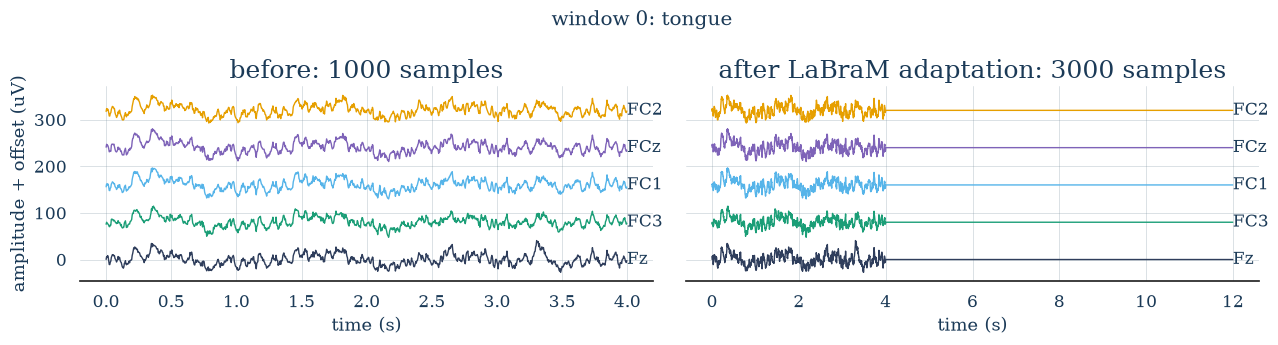

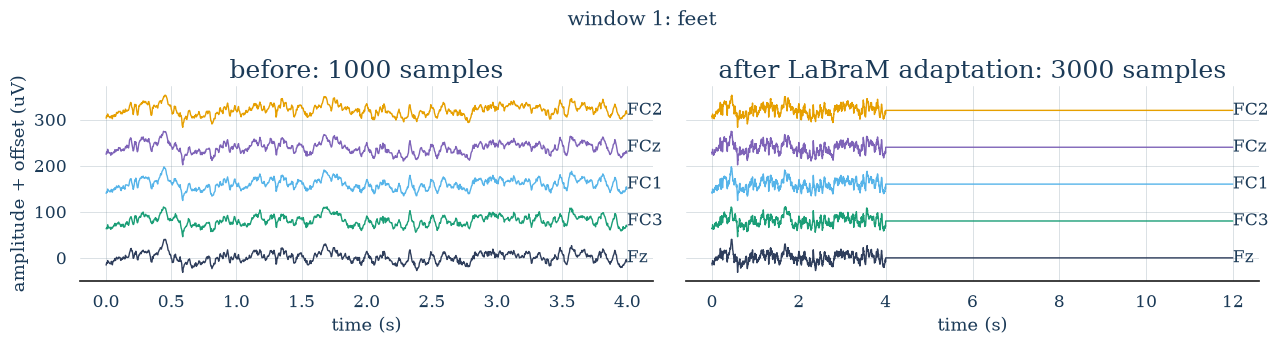

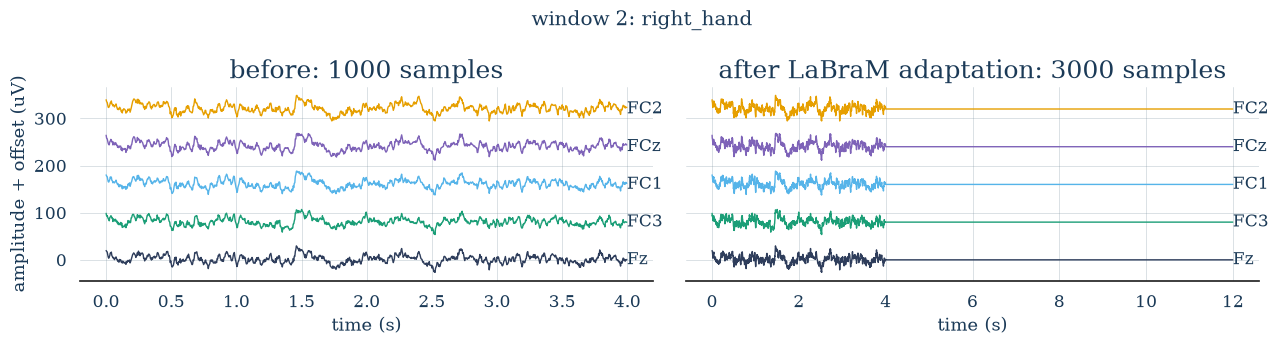

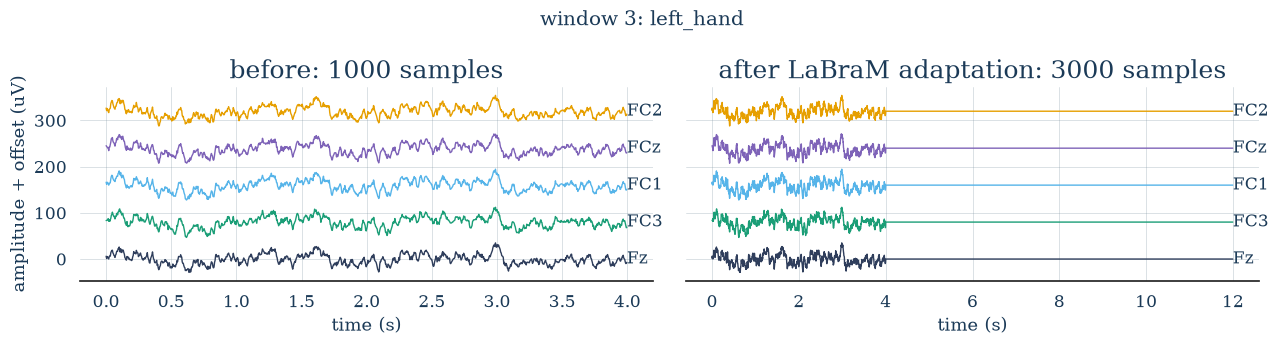

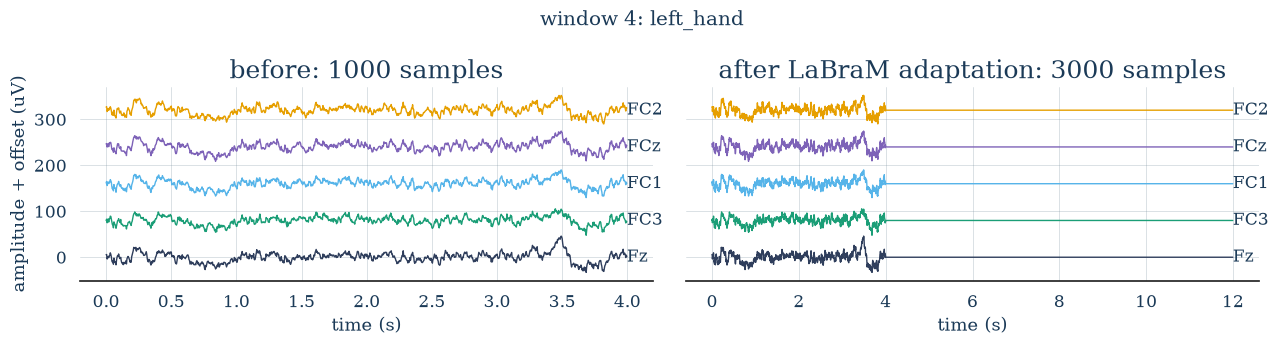

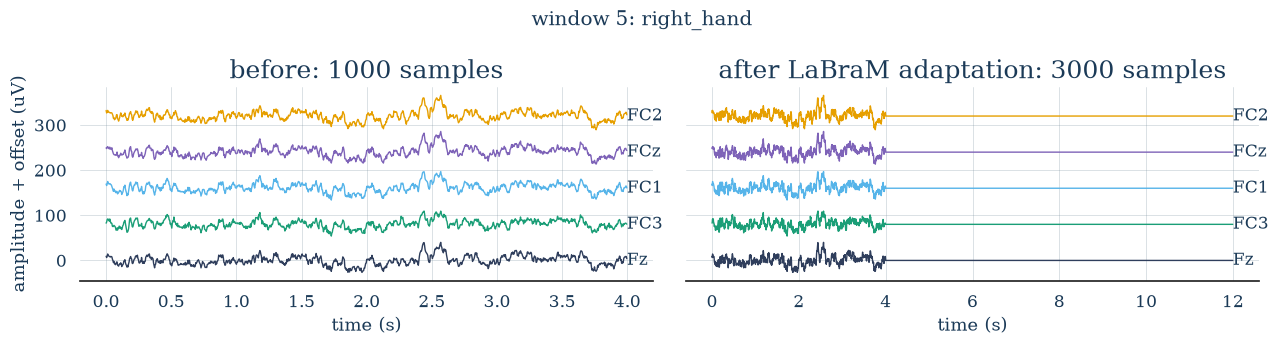

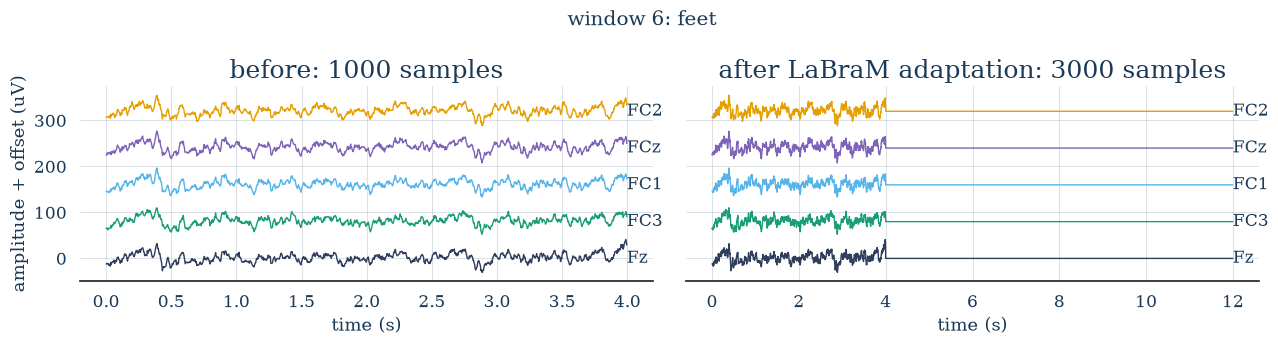

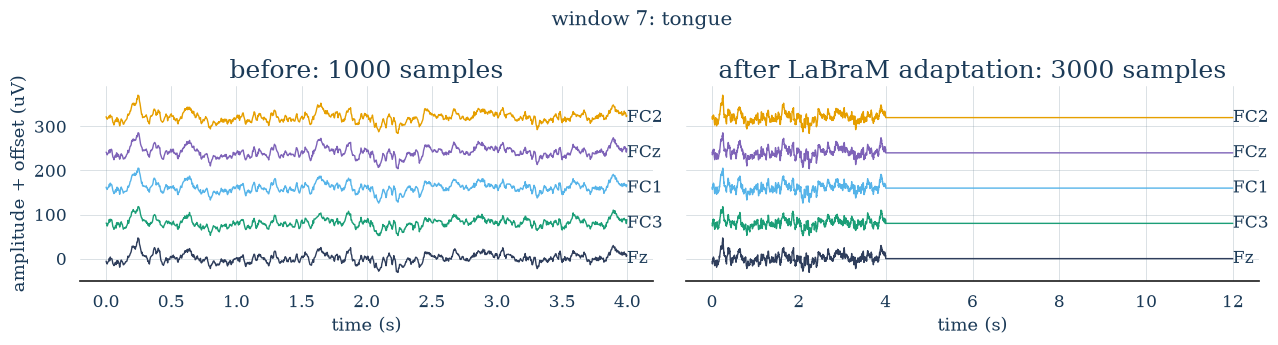

In [14]:
def plot_window_pair(index, before, after, label):
    before_time_s = np.arange(before.shape[-1]) / sfreq
    after_time_s = np.arange(after.shape[-1]) / sfreq

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
    for ax, title, values, time_s in [
        (axes[0], "before", before, before_time_s),
        (axes[1], "after LaBraM adaptation", after, after_time_s),
    ]:
        for channel_index, channel_name in enumerate(channels_to_plot):
            offset_uv = channel_index * 80
            ax.plot(time_s, values[channel_index].numpy() + offset_uv, linewidth=1)
            ax.text(time_s[-1], offset_uv, channel_name, va="center", ha="left")
        ax.set_title(f"{title}: {values.shape[-1]} samples")
        ax.set_xlabel("time (s)")

    axes[0].set_ylabel("amplitude + offset (uV)")
    fig.suptitle(f"window {index}: {id_to_event[label]}")
    plt.tight_layout()


for index, ((before, label, _), (after, _, _)) in enumerate(
    zip(before_windows, after_windows, strict=True)
):
    plot_window_pair(index, before, after, label)